In [2]:
import numpy as np
import pandas as pd

url = "https://hilpisch.com/nov25eod.csv"

panel = pd.read_csv(
    url,
    index_col=0,
    parse_dates = True,
)

panel = panel.sort_index()

print(panel.info())
print(panel.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-11-30 to 2025-11-28
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL     2515 non-null   float64
 1   NVDA     2515 non-null   float64
 2   JPM      2515 non-null   float64
 3   SPY      2515 non-null   float64
 4   GLD      2515 non-null   float64
 5   TLT      2515 non-null   float64
 6   EURUSD   2203 non-null   float64
 7   BTC-USD  2515 non-null   float64
dtypes: float64(8)
memory usage: 176.8 KB
None
              AAPL    NVDA     JPM     SPY     GLD    TLT  EURUSD  \
Date                                                                
2025-11-21  271.49  178.88  298.02  659.03  374.27  89.50  1.1513   
2025-11-24  275.92  182.55  298.00  668.73  380.20  90.01  1.1520   
2025-11-25  276.97  177.82  303.00  675.02  380.08  90.24  1.1565   
2025-11-26  277.55  180.26  307.64  679.68  383.12  90.64  1.1602   
2025-11-28  278.85  177.00  313.08 

In [3]:
import numpy as np
import pandas as pd

# pick one asset
asset = "NVDA" 
prices = panel[asset].astype(float).dropna()

# simple return
rets = prices.pct_change().dropna()

# SMA crossover
fast_win, slow_win = 20,100
ma_fast = prices.rolling(fast_win).mean()
ma_slow = prices.rolling(slow_win).mean()

signal = (ma_fast > ma_slow).astype(float)   # s_t is 0 or 1
position = signal.shift(1).reindex(rets.index).fillna(0.0)  # q_t = s _{t-1}

# strategy return
str_ret = position * rets

#equity wealth
wealth = (1+str_ret) .cumprod()

#cummulative return
cum_return = wealth.iloc[-1] -1.0

#max drowdown
running_max = wealth.cummax()
drawdown = wealth / running_max -1
max_drawdown = drawdown.min()

print(f"Asset: {asset}")
print(f"Cumulative return: {cum_return:.4%}")
print(f"Max drawdown: {max_drawdown:.4%}")

Asset: NVDA
Cumulative return: 7674.6422%
Max drawdown: -49.0030%


In [3]:
import numpy as np
import pandas as pd

# pick one asset
asset = "NVDA" 
prices = panel[asset].astype(float).dropna()

# simple return
rets = prices.pct_change().dropna()

# z-score mean reversion
lookback = 60
z_high, z_low = 2.0,-2.0

ma = prices.rolling(lookback).mean()
sd = prices.rolling(lookback).std()
z = (prices - ma) / sd

# signal
signal = pd.Series(0.0, index= prices.index)
signal[z > z_high] = -1.0
signal[z < z_low] = 1.0

# trade position
position = signal.shift(1).reindex(rets.index).fillna(0.0)

#strategy return
str_return = position * rets

#equity wealth
wealth = (1.0+str_ret) .cumprod()

#cummulative return
cum_return = wealth.iloc[-1] -1.0

#max drowdown
running_max = wealth.cummax()
drawdown = wealth / running_max -1
max_drawdown = drawdown.min()

print(f"Asset: {asset}")
print(f"Z-score MR: lookback={lookback}, z_low={z_low}, z_high={z_high}")
print(f"Cumulative return: {cum_return:.4%}")
print(f"Max drawdown: {max_drawdown:.4%}")

Asset: NVDA
Z-score MR: lookback=60, z_low=-2.0, z_high=2.0
Cumulative return: 7674.6422%
Max drawdown: -49.0030%


In [4]:
## when changing the z score threshold and lookback, the cumulative return and max drawdown don't change. 
## test if the signal triggered

print("prices head:\n", prices.head())
print("rets head:\n", rets.head())

print("\nRolling std (sd) summary:")
print(sd.describe())

print("\nZ-score summary:")
print(z.replace([np.inf, -np.inf], np.nan).describe())

print("\nHow often z exceeds thresholds:")
print("z > z_high:", int((z > z_high).sum()))
print("z < z_low :", int((z < z_low).sum()))

print("\nSignal counts:")
print(signal.value_counts(dropna=False))

print("\nPosition counts:")
print(position.value_counts(dropna=False))

print("\nStrategy returns summary:")
print(str_ret.describe())

## the signal triggered.

prices head:
 Date
2015-11-30    0.7738
2015-12-01    0.7989
2015-12-02    0.7928
2015-12-03    0.7911
2015-12-04    0.8233
Name: NVDA, dtype: float64
rets head:
 Date
2015-12-01    0.032437
2015-12-02   -0.007635
2015-12-03   -0.002144
2015-12-04    0.040703
2015-12-07   -0.018948
Name: NVDA, dtype: float64

Rolling std (sd) summary:
count    2456.000000
mean        2.990132
std         4.290817
min         0.049082
25%         0.326891
50%         1.065487
75%         3.198378
max        19.121222
Name: NVDA, dtype: float64

Z-score summary:
count    2456.000000
mean        0.748973
std         1.279190
min        -3.554264
25%        -0.089283
50%         1.037421
75%         1.654722
max         4.936974
Name: NVDA, dtype: float64

How often z exceeds thresholds:
z > z_high: 330
z < z_low : 60

Signal counts:
 0.0    2125
-1.0     330
 1.0      60
Name: count, dtype: int64

Position counts:
 0.0    2124
-1.0     330
 1.0      60
Name: count, dtype: int64

Strategy returns summary:


In [5]:
## test with different z score threshold 

import numpy as np
import pandas as pd

asset = "NVDA"
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()

lookback = 100
ma = prices.rolling(lookback).mean()
sd = prices.rolling(lookback).std()
z = (prices - ma) / sd

def run(th):
    z_high, z_low = th, -th
    signal = pd.Series(0.0, index=prices.index)
    signal[z > z_high] = -1.0
    signal[z < z_low]  =  1.0
    position = signal.shift(1).reindex(rets.index).fillna(0.0)
    strat_ret = position * rets
    wealth = (1.0 + strat_ret).cumprod()
    cum_return = wealth.iloc[-1] - 1.0
    dd = wealth / wealth.cummax() - 1.0
    max_dd = dd.min()
    return int((position != 0).sum()), cum_return, max_dd

for th in [0.5, 1.0, 1.5, 2.0, 2.5]:
    trades_days, cr, mdd = run(th)
    print(f"th={th:>3}: nonzero_days={trades_days:4d}, cum_return={cr:9.2%}, max_dd={mdd:8.2%}")

## it seems work. why in the earlier block, the printed result never changed?

th=0.5: nonzero_days=2052, cum_return=  -99.16%, max_dd= -99.31%
th=1.0: nonzero_days=1608, cum_return=  -98.09%, max_dd= -98.68%
th=1.5: nonzero_days=1071, cum_return=  -92.00%, max_dd= -93.79%
th=2.0: nonzero_days= 491, cum_return=  -43.83%, max_dd= -64.45%
th=2.5: nonzero_days= 182, cum_return=  -28.12%, max_dd= -47.86%


In [6]:
import numpy as np
import pandas as pd

asset = "NVDA"
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()

lookback = 100
th = 2  #threshold
cost_rate = 0.0005

ma = prices.rolling(lookback).mean()
sd = prices.rolling(lookback).std()
z = (prices - ma) / sd

signal = pd.Series(0.0, index= prices.index)
signal[z > th] = -1.0
signal[z < -th] = 1.0

position = signal.shift(1).reindex(rets.index).fillna(0.0)

# return no cost
ret_gross = position * rets
wealth_gross = (1.0 + ret_gross).cumprod()

# add cost
delta_q = position.diff().fillna(position)
costs = cost_rate * delta_q.abs()
ret_net = ret_gross - costs
wealth_net = (1.0 + ret_net).cumprod()

# --- metrics helper ---
def metrics(wealth):
    cum_return = wealth.iloc[-1] - 1.0
    dd = wealth / wealth.cummax() - 1.0
    max_dd = dd.min()
    return cum_return, max_dd

cr_g, mdd_g = metrics(wealth_gross)
cr_n, mdd_n = metrics(wealth_net)

print(f"Asset: {asset}")
print(f"Z-score MR: lookback={lookback}, threshold=±{th}")
print(f"Cost rate: {cost_rate} per unit turnover")
print(f"Trades/turnover days: {(delta_q != 0).sum()}")

print("\nCost-free baseline:")
print(f"  Cumulative return: {cr_g:.2%}")
print(f"  Max drawdown:      {mdd_g:.2%}")

print("\nNet of transaction costs:")
print(f"  Cumulative return: {cr_n:.2%}")
print(f"  Max drawdown:      {mdd_n:.2%}")

Asset: NVDA
Z-score MR: lookback=100, threshold=±2
Cost rate: 0.0005 per unit turnover
Trades/turnover days: 194

Cost-free baseline:
  Cumulative return: -43.83%
  Max drawdown:      -64.45%

Net of transaction costs:
  Cumulative return: -49.02%
  Max drawdown:      -67.27%


In [7]:
import numpy as np
import pandas as pd

# --- choose asset ---
asset = "NVDA"   
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()

# --- helpers ---
def backtest_sma(fast, slow, cost_rate=0.0):
    ma_fast = prices.rolling(fast).mean()
    ma_slow = prices.rolling(slow).mean()

    signal = (ma_fast > ma_slow).astype(float)                    # long-only: {0,1}
    position = signal.shift(1).reindex(rets.index).fillna(0.0)    # q_t = s_{t-1}

    gross_ret = position * rets

    # turnover & (optional) transaction costs
    delta_q = position.diff().fillna(position)     # assume starting from 0
    turnover = delta_q.abs().sum()                 # total turnover (L1)
    trades = int((delta_q != 0).sum())             # number of position changes

    costs = cost_rate * delta_q.abs()
    net_ret = gross_ret - costs

    wealth = (1.0 + net_ret).cumprod()
    cum_return = wealth.iloc[-1] - 1.0

    dd = wealth / wealth.cummax() - 1.0
    max_dd = dd.min()

    return cum_return, max_dd, turnover, trades

# --- parameter grid ---
fast_list = [5, 10, 20, 30, 40]
slow_list = [50, 100, 150, 200]
cost_rate = 0.0000   # set e.g. 0.0005 if you want costs included

rows = []
for fast in fast_list:
    for slow in slow_list:
        if fast >= slow:
            continue
        cr, mdd, to, tr = backtest_sma(fast, slow, cost_rate=cost_rate)
        rows.append({
            "fast": fast,
            "slow": slow,
            "cum_return": cr,
            "max_drawdown": mdd,
            "turnover_sum_abs_dq": to,
            "position_changes": tr,
        })

results = pd.DataFrame(rows).sort_values(["cum_return"], ascending=False).reset_index(drop=True)

# --- summary outputs ---
print(f"Asset: {asset} | cost_rate={cost_rate}")
print("\nTop 10 by cumulative return:")
print(results.head(10).to_string(index=False))

print("\nBottom 10 by cumulative return:")
print(results.tail(10).to_string(index=False))

# heatmap-style tables (good for seeing grid patterns)
perf_grid = results.pivot(index="fast", columns="slow", values="cum_return")
turn_grid = results.pivot(index="fast", columns="slow", values="turnover_sum_abs_dq")

print("\nCumulative return grid (rows=fast, cols=slow):")
print(perf_grid.round(4))

print("\nTurnover grid (sum |Δq|, rows=fast, cols=slow):")
print(turn_grid.round(2))

# quick relationship check (do faster MAs trade more?)
print("\nCorrelation (cum_return vs turnover):",
      results["cum_return"].corr(results["turnover_sum_abs_dq"]))

Asset: NVDA | cost_rate=0.0

Top 10 by cumulative return:
 fast  slow  cum_return  max_drawdown  turnover_sum_abs_dq  position_changes
   40   150  177.578301     -0.456865                  9.0                 9
   40   200  142.899421     -0.375531                  7.0                 7
   10   100  131.645687     -0.451700                 31.0                31
   30   100  131.590095     -0.458022                 23.0                23
   40   100  127.760977     -0.467637                 19.0                19
   30   200  123.246964     -0.418252                  7.0                 7
   20   150  122.036007     -0.507323                 17.0                17
   10   200  115.590610     -0.487121                 13.0                13
    5   200  106.224286     -0.538210                 17.0                17
   30   150   98.713336     -0.559255                 13.0                13

Bottom 10 by cumulative return:
 fast  slow  cum_return  max_drawdown  turnover_sum_abs_dq  po

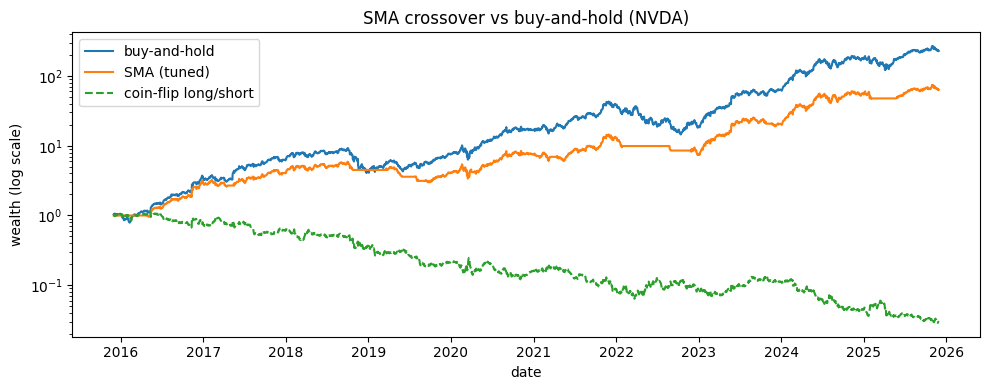

In [8]:
import matplotlib.pyplot as plt

asset = "NVDA"
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()

# SMA crossover
fast_win, slow_win = 20,100
ma_fast = prices.rolling(fast_win).mean()
ma_slow = prices.rolling(slow_win).mean()

signal_longonly = (ma_fast > ma_slow).astype(float)

pos_longonly = signal_longonly.shift(1).reindex(rets.index).fillna(0.0)

cost_rate = 0.0005
fin_rate = 0.0001
delta_q = pos_longonly.diff().fillna(pos_longonly)
cost = cost_rate * delta_q.abs()
financing = fin_rate * pos_longonly.abs()

str_ret = pos_longonly*rets -cost - financing
wealth_sma = (1.0 + str_ret).cumprod()

# buy and hold
wealth_bh = (1.0 + rets).cumprod()

# flip coin
rng = np.random.default_rng(0)
coin_pos = pd.Series(rng.choice([-1.0, 1.0], size=len(rets)), index=rets.index)

coin_delta = coin_pos.diff().fillna(coin_pos)          # turnover from 0 on first day
coin_costs = cost_rate * coin_delta.abs()
coin_fin   = fin_rate * coin_pos.abs()

coin_ret = coin_pos * rets - coin_costs - coin_fin


wealth_coin = (1.0 + coin_ret).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(wealth_bh.index, wealth_bh.values, label="buy-and-hold")
plt.plot(wealth_sma.index, wealth_sma.values, label="SMA (tuned)")
plt.plot(wealth_coin.index, wealth_coin.values, linestyle="--", label="coin-flip long/short")
plt.yscale("log")
plt.title(f"SMA crossover vs buy-and-hold ({asset})")
plt.xlabel("date")
plt.ylabel("wealth (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## chapter 8

In [9]:
import numpy as np
import pandas as pd

# --- choose asset ---
asset = "NVDA"   
prices = panel[asset].astype(float).dropna()

# calculate log return for y_t
log_ret = np.log(prices / prices.shift(1)).dropna()

# lagged return predicators.
L = 10  # number of lags
X = pd.concat({f"lag{lag}": log_ret.shift(lag) for lag in range(1,L+1)}, axis = 1).dropna()
y = log_ret.reindex(X.index).dropna()
X = X.reindex(y.index)

# split the dataset
n = len(X)
split = int(0.7 *n)

X_train_df, X_test_df = X.iloc[:split], X.iloc[split:]
y_train_s, y_test_s = y.iloc[:split],y.iloc[split:]

# standardize the train
mu = X_train_df.mean()
sd = X_train_df.std(ddof=0).replace(0.0, np.nan)

X_train = ((X_train_df - mu) / sd).fillna(0.0).to_numpy()
X_test  = ((X_test_df  - mu) / sd).fillna(0.0).to_numpy()

y_train = y_train_s.to_numpy()
y_test  = y_test_s.to_numpy()

# solve beta and get ols prediction
X_design = np.column_stack([np.ones(len(y_train)), X_train])  # add intercept column
xtx = X_design.T @ X_design
xty = X_design.T @ y_train
beta = np.linalg.solve(xtx, xty)

def ols_predict(beta, X_np):
    Xd = np.column_stack([np.ones(X_np.shape[0]), X_np])
    return Xd @ beta

yhat_train = ols_predict(beta, X_train)
yhat_test  = ols_predict(beta, X_test)

# out of sample evaluation
def r2_score(y_true, y_pred):
    resid = y_true - y_pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

r2_in  = r2_score(y_train, yhat_train)
r2_oos = r2_score(y_test,  yhat_test)


corr_oos = np.corrcoef(y_test, yhat_test)[0, 1]

print(f"Asset: {asset}")
print(f"Lag predictors: L={L}")
print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"In-sample R^2:  {r2_in:.4f}")
print(f"OOS R^2:        {r2_oos:.4f}")
print(f"OOS corr(y,ŷ):  {corr_oos:.4f}")
print("\nFirst 5 OOS preds vs actual:")
print(pd.DataFrame({"y_true": y_test_s.iloc[:5].values, "y_pred": yhat_test[:5]}, index=y_test_s.index[:5]))

## I tried lag = 3, 5, 10. none of them shows very good prediction

Asset: NVDA
Lag predictors: L=10
Train size: 1752, Test size: 752
In-sample R^2:  0.0243
OOS R^2:        -0.0252
OOS corr(y,ŷ):  -0.0066

First 5 OOS preds vs actual:
              y_true    y_pred
Date                          
2022-11-30  0.079163 -0.000099
2022-12-01  0.012450 -0.006340
2022-12-02 -0.015227  0.005459
2022-12-05 -0.015891  0.004659
2022-12-06 -0.038228  0.001779


In [10]:
import numpy as np
import pandas as pd

asset = "NVDA"   
prices = panel[asset].astype(float).dropna()
log_ret = np.log(prices / prices.shift(1)).dropna()

L = 10
X_df = pd.concat({f"lag{lag}": log_ret.shift(lag) for lag in range(1, L + 1)}, axis=1).dropna()
y_s = log_ret.reindex(X_df.index).dropna()
X_df = X_df.reindex(y_s.index)

n = len(X_df)
split = int(0.7 * n)

X_train_df = X_df.iloc[:split]
y_train = y_s.iloc[:split].to_numpy()

# no scaling the data

# define a function to find beta
def fit_ols_beta(X_np, y_np):
    X_design = np.column_stack([np.ones(len(y_np)), X_np])  # intercept
    beta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y_np)
    return beta  # length = 1 + k

# (A) Fit WITHOUT scaling 
beta_raw = fit_ols_beta(X_train_df.to_numpy(), y_train)

# (B) Fit WITH feature standardization (train stats only) 
mu = X_train_df.mean()
sd = X_train_df.std(ddof=0).replace(0.0, np.nan)
X_train_scaled = ((X_train_df - mu) / sd).fillna(0.0).to_numpy()

# beta using sclling
beta_scaled = fit_ols_beta(X_train_scaled, y_train)

#  Compare "stability" two ways 
XtX_raw = np.column_stack([np.ones(len(y_train)), X_train_df.to_numpy()])
XtX_raw = XtX_raw.T @ XtX_raw
cond_raw = np.linalg.cond(XtX_raw)

XtX_scaled = np.column_stack([np.ones(len(y_train)), X_train_scaled])
XtX_scaled = XtX_scaled.T @ XtX_scaled
cond_scaled = np.linalg.cond(XtX_scaled)

# 2) Coefficient sensitivity to tiny noise in y 
# to see the change of beta ( stability of beta) based on diffenet  data set ( scaled or not)
def beta_sensitivity(X_np, y_np, trials=200, noise_scale=1e-4, seed=0):
    rng = np.random.default_rng(seed)
    betas = []
    for _ in range(trials):
        y_noisy = y_np + rng.normal(0.0, noise_scale, size=len(y_np))
        betas.append(fit_ols_beta(X_np, y_noisy))
    betas = np.vstack(betas)
    return betas.std(axis=0)  # std of each coefficient across trials

beta_std_raw = beta_sensitivity(X_train_df.to_numpy(), y_train, trials=200, noise_scale=1e-4, seed=1)
beta_std_scaled = beta_sensitivity(X_train_scaled, y_train, trials=200, noise_scale=1e-4, seed=1)

# ===== Report =====
coef_names = ["intercept"] + list(X_train_df.columns)

out = pd.DataFrame({
    "coef": coef_names,
    "beta_raw": beta_raw,
    "beta_scaled": beta_scaled,
    "std_beta_raw": beta_std_raw,
    "std_beta_scaled": beta_std_scaled,
})

print(f"Asset: {asset}, L={L}, train_n={len(y_train)}")
print(f"Condition number (X'X) raw:    {cond_raw:.2e}")
print(f"Condition number (X'X) scaled: {cond_scaled:.2e}")
print("\nCoefficient comparison (values and sensitivity to small y-noise):")
print(out.to_string(index=False))

# raw data has a beta with higher volatility and moves bigger ( not stable).

Asset: NVDA, L=10, train_n=1752
Condition number (X'X) raw:    1.24e+03
Condition number (X'X) scaled: 1.64e+00

Coefficient comparison (values and sensitivity to small y-noise):
     coef  beta_raw  beta_scaled  std_beta_raw  std_beta_scaled
intercept  0.001737     0.001700      0.000002         0.000002
     lag1 -0.069631    -0.002160      0.000075         0.000002
     lag2  0.034088     0.001057      0.000073         0.000002
     lag3  0.024248     0.000752      0.000081         0.000003
     lag4 -0.001510    -0.000047      0.000072         0.000002
     lag5  0.000961     0.000030      0.000077         0.000002
     lag6 -0.042714    -0.001324      0.000077         0.000002
     lag7  0.075091     0.002329      0.000077         0.000002
     lag8 -0.069680    -0.002161      0.000076         0.000002
     lag9  0.028094     0.000871      0.000076         0.000002
    lag10 -0.001899    -0.000059      0.000077         0.000002


In [11]:
import numpy as np
import pandas as pd

asset = "NVDA"   
prices = panel[asset].astype(float).dropna()
log_ret = np.log(prices / prices.shift(1)).dropna()

#  Build lagged-return predictors (X) and target (y)
L = 10
X_df = pd.concat({f"lag{lag}": log_ret.shift(lag) for lag in range(1, L + 1)}, axis=1).dropna()
y_s = log_ret.reindex(X_df.index).dropna()
X_df = X_df.reindex(y_s.index)

#  SPLIT THE DATA
n = len(X_df)
split = int(0.7 * n)

X_train_df, X_test_df = X_df.iloc[:split], X_df.iloc[split:]
y_train_s, y_test_s   = y_s.iloc[:split], y_s.iloc[split:]

mu = X_train_df.mean()
sd = X_train_df.std(ddof=0).replace(0.0, np.nan)

X_train = ((X_train_df - mu) / sd).fillna(0.0).to_numpy()
X_test  = ((X_test_df  - mu) / sd).fillna(0.0).to_numpy()

y_train = y_train_s.to_numpy()
y_test  = y_test_s.to_numpy()

#  4) Fit OLS 
X_design = np.column_stack([np.ones(len(y_train)), X_train])
beta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y_train)

def ols_predict(beta, X_np):
    Xd = np.column_stack([np.ones(X_np.shape[0]), X_np])
    return Xd @ beta

yhat_test = ols_predict(beta, X_test)

#  5) Predicted-return signal
entry_th = 0.0010             # predicted return threshold (log-return units)
leverage = 1.0
cost_rate = 0.0002            

pred = pd.Series(yhat_test, index=X_test_df.index, name="yhat")

signal = pd.Series(0.0, index=pred.index)
signal[pred >  entry_th] =  1.0
signal[pred < -entry_th] = -1.0

# tradable position (avoid look-ahead) and align with returns
position = (leverage * signal.shift(1)).fillna(0.0)
rets_test = log_ret.reindex(position.index)

# Backtest with transaction costs 
gross_ret = position * rets_test

delta_q = position.diff().fillna(position)     # assume start from 0
costs = cost_rate * delta_q.abs()              # C_t = c * |Δq_t|
net_ret = gross_ret - costs

wealth = (1.0 + net_ret).cumprod()

cum_return = wealth.iloc[-1] - 1.0
dd = wealth / wealth.cummax() - 1.0
max_dd = dd.min()
trades = int((delta_q != 0).sum())

print(f"Asset: {asset}")
print(f"OLS lag model: L={L}, train={split}, test={n-split}")
print(f"Signal rule: long if yhat>{entry_th}, short if yhat<-{entry_th}, else flat")
print(f"Cost rate: {cost_rate} per unit turnover | Trades: {trades}")
print(f"Cumulative return (net): {cum_return:.2%}")
print(f"Max drawdown: {max_dd:.2%}")
print("Final wealth:", float(wealth.iloc[-1]))


Asset: NVDA
OLS lag model: L=10, train=1752, test=752
Signal rule: long if yhat>0.001, short if yhat<-0.001, else flat
Cost rate: 0.0002 per unit turnover | Trades: 535
Cumulative return (net): -41.67%
Max drawdown: -78.72%
Final wealth: 0.5833131289645115


In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor


asset = "NVDA"   
prices = panel[asset].astype(float).dropna()
log_ret = np.log(prices / prices.shift(1)).dropna()  # y_t

# lags definiation
L = 10
X_df = pd.concat({f"lag{lag}": log_ret.shift(lag) for lag in range(1, L + 1)}, axis=1).dropna()
y_s = log_ret.reindex(X_df.index).dropna()
X_df = X_df.reindex(y_s.index)

# time split
n = len(X_df)
split = int(0.7 * n)
X_train_df, X_test_df = X_df.iloc[:split], X_df.iloc[split:]
y_train_s, y_test_s = y_s.iloc[:split], y_s.iloc[split:]

# standardize using TRAIN stats only 
mu = X_train_df.mean()
sd = X_train_df.std(ddof=0).replace(0.0, np.nan)
X_train = ((X_train_df - mu) / sd).fillna(0.0).to_numpy()
X_test  = ((X_test_df  - mu) / sd).fillna(0.0).to_numpy()
y_train = y_train_s.to_numpy()
y_test  = y_test_s.to_numpy()
y_test_series = pd.Series(y_test, index=y_test)

#  OLS baseline
X_design = np.column_stack([np.ones(len(y_train)), X_train])
beta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y_train)

def ols_predict(beta, X_np):
    Xd = np.column_stack([np.ones(X_np.shape[0]), X_np])
    return Xd @ beta

yhat_ols = ols_predict(beta, X_test)


# Non-linear model: Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=50,
    random_state=7,
    n_jobs=-1
)
rf.fit(X_train, y_train)
yhat_rf = rf.predict(X_test)


# Compare predictive performance using out of sample data
def r2_score(y_true, y_pred):
    resid = y_true - y_pred
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1.0 - ss_res / ss_tot

def corr(y_true, y_pred):
    return float(np.corrcoef(y_true, y_pred)[0, 1])

print(f"Asset: {asset} | L={L} | Train={split} Test={n-split}")
print("\nOut-of-sample predictive metrics:")
print(f"OLS : R^2={float(r2_score(y_test, yhat_ols)):.4f}, corr={float(corr(y_test, yhat_ols)):.4f}")
print(f"RF  : R^2={float(r2_score(y_test, yhat_rf)):.4f}, corr={float(corr(y_test, yhat_rf)):.4f}")

## testing the performance if trade
def backtest_gross(yhat, idx, y_true, threshold=0.0, shift_pos=True):
    pred = pd.Series(yhat, index=idx)
    signal = pd.Series(0.0, index=idx)
    signal[pred >  threshold] =  1.0
    signal[pred < -threshold] = -1.0

    position = signal.shift(1).fillna(0.0) if shift_pos else signal
    strat_ret = position * y_true

    wealth = (1.0 + strat_ret).cumprod()
    cum_return = wealth.iloc[-1] - 1.0
    dd = wealth / wealth.cummax() - 1.0
    max_dd = dd.min()
    sharpe = (strat_ret.mean() / strat_ret.std(ddof=0)) * np.sqrt(252) if strat_ret.std(ddof=0) != 0 else np.nan
    return cum_return, max_dd, sharpe

cr_ols, mdd_ols, sh_ols = backtest_gross(yhat_ols, y_test, y_test_series, threshold=0.0)
cr_rf,  mdd_rf,  sh_rf  = backtest_gross(yhat_rf,  y_test, y_test_series, threshold=0.0)

print("\nCost-free trading comparison (sign strategy):")
print(f"OLS: cum_return={cr_ols:.2%}, max_dd={mdd_ols:.2%}, sharpe={sh_ols:.2f}")
print(f"RF : cum_return={cr_rf:.2%}, max_dd={mdd_rf:.2%}, sharpe={sh_rf:.2f}")

## RF improve the result a lot. means the relationship between y and X is not linear

Asset: NVDA | L=10 | Train=1752 Test=752

Out-of-sample predictive metrics:
OLS : R^2=-0.0252, corr=-0.0066
RF  : R^2=-0.0113, corr=0.0243

Cost-free trading comparison (sign strategy):
OLS: cum_return=-39.00%, max_dd=-80.22%, sharpe=-0.07
RF : cum_return=101.40%, max_dd=-74.01%, sharpe=0.72


Residual mean: 0.0015728792670874822
Residual std : 0.03209095835921748

Residual autocorr (first 10 lags):
1    -0.000584
2     0.006365
3    -0.113239
4    -0.016305
5    -0.006960
6     0.088413
7    -0.073458
8     0.105514
9    -0.019705
10   -0.041089
dtype: float64


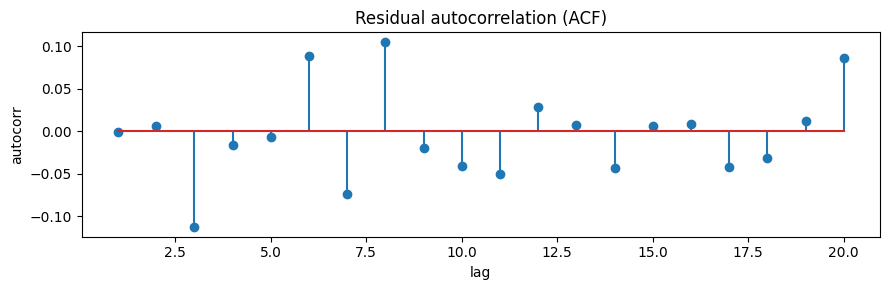


Squared residual autocorr (first 10 lags):
1     0.041547
2     0.018150
3     0.038790
4     0.036882
5     0.044849
6     0.017871
7     0.030037
8     0.006782
9    -0.001380
10    0.009192
dtype: float64


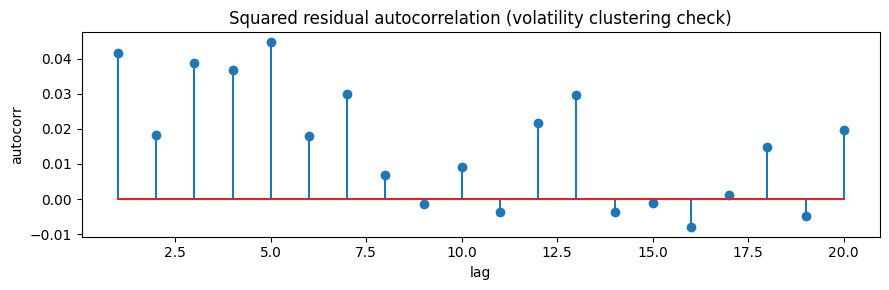

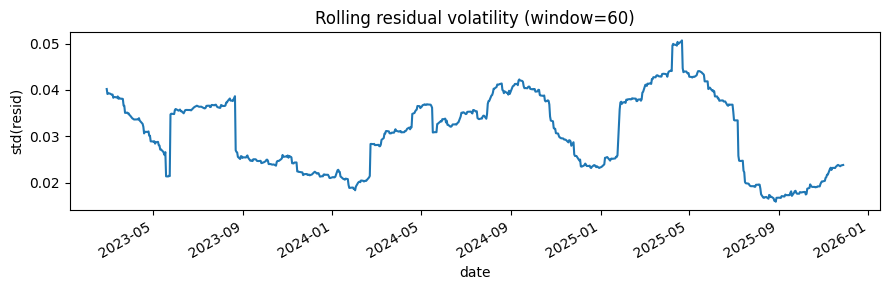

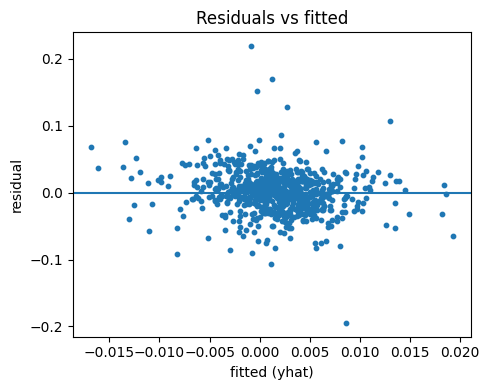

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


yhat_s = pd.Series(yhat_ols, index=y_test_s.index, name="yhat")
resid = (y_test_s - yhat_s).rename("resid")

print("Residual mean:", float(resid.mean()))
print("Residual std :", float(resid.std(ddof=0)))


#  Autocorrelation function (residuals) p_k = corr(e_t, e_{t-k})
# assumption: errors are not serially correlated
max_lag = 20
acf = pd.Series({lag: resid.autocorr(lag=lag) for lag in range(1, max_lag + 1)})
print("\nResidual autocorr (first 10 lags):")
print(acf.head(10))

plt.figure(figsize=(9, 3))
plt.stem(acf.index, acf.values)
plt.title("Residual autocorrelation (ACF)")
plt.xlabel("lag")
plt.ylabel("autocorr")
plt.tight_layout()
plt.show()

# there are several residual not independent. the model can still include some information




# Heteroskedasticity / volatility clustering
#   (look at residual^2 autocorr + rolling volatility)
#  violate volatility clustering?
# assumption: is variance of errors constant?

resid2 = (resid ** 2).rename("resid2")
acf2 = pd.Series({lag: resid2.autocorr(lag=lag) for lag in range(1, max_lag + 1)})
print("\nSquared residual autocorr (first 10 lags):")
print(acf2.head(10))

plt.figure(figsize=(9, 3))
plt.stem(acf2.index, acf2.values)
plt.title("Squared residual autocorrelation (volatility clustering check)")
plt.xlabel("lag")
plt.ylabel("autocorr")
plt.tight_layout()
plt.show()

# acf2 is almost all positive. it means the volatility clustering.
# rolling residual also shows s lot moves. the variance is not stable


roll = 60
plt.figure(figsize=(9, 3))
resid.rolling(roll).std(ddof=0).plot()
plt.title(f"Rolling residual volatility (window={roll})")
plt.xlabel("date")
plt.ylabel("std(resid)")
plt.tight_layout()
plt.show()

# residuals vs fitted (variance changing with level?)
# there is no obvious relationship. that means the model has explain most of the information and leaving the random stuff
plt.figure(figsize=(5, 4))
plt.scatter(yhat_s, resid, s=10)
plt.axhline(0.0)
plt.title("Residuals vs fitted")
plt.xlabel("fitted (yhat)")
plt.ylabel("residual")
plt.tight_layout()
plt.show()

In [ ]:
## Chapter 9

In [ ]:
## 1. market / data comes in
## 2. strategy process the data and generate a signal event
## 3. then transfer the signal into an order
## 4. calculate the new P&L after the fees and costs.

In [ ]:
## 2. don't know how to do it...
## is it a question asking for writing code?
## or just describe in word how the loop is doing?

## design a strategy
## feed the data
## detect signal
## calculate order data
## get P&L
## store this information for next day
## loop


In [4]:
## with a limitation of the notional size based on the volatility such as sigma or DV01
## can help the trade avoid too much risk
## it is a method of risk controlling
## but instead of 1 trade, you might get to trade several times to meet some target

import numpy as np
import pandas as pd


#  get Data 
asset = "NVDA"   
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()   # simple daily returns R_t

# Directional signal: SMA crossover 
fast_win, slow_win = 20, 100
ma_fast = prices.rolling(fast_win).mean()
ma_slow = prices.rolling(slow_win).mean()

# s_t in {0,1}: long when fast>slow else flat
signal = (ma_fast > ma_slow).astype(float)

# Volatility-based position sizing (vol targeting) 
vol_win = 20
sigma = rets.rolling(vol_win).std(ddof=0)

sigma_target = 0.01   
q_max = 2.0           # max leverage 

# size_t = clip(sigma_target / sigma_t, 0, q_max)
size = (sigma_target / sigma).clip(lower=0.0, upper=q_max)

# Tradable position: use yesterday's signal and yesterday's size 
position = (signal.shift(1) * size.shift(1)).reindex(rets.index).fillna(0.0)

# "Order events" implied by position changes 
#  order size is Δq_t = q_t - q_{t-1}.
delta_q = position.diff().fillna(position)  

# Order count and turnover
order_count = int((delta_q != 0).sum())
turnover_L1 = float(delta_q.abs().sum())

#Backtest with proportional transaction costs
cost_rate = 0.0005  
costs = cost_rate * delta_q.abs()

gross_ret = position * rets
net_ret = gross_ret - costs
wealth = (1.0 + net_ret).cumprod()

cum_return = float(wealth.iloc[-1] - 1.0)
drawdown = wealth / wealth.cummax() - 1.0
max_dd = float(drawdown.min())

print(f"Asset: {asset}")
print(f"SMA: fast={fast_win}, slow={slow_win}")
print(f"Vol sizing: vol_win={vol_win}, sigma_target={sigma_target}, q_max={q_max}")
print(f"Order events (position changes): {order_count}")
print(f"Total turnover (sum |Δq|): {turnover_L1:.2f}")
print(f"Cumulative return (net): {cum_return:.2%}")
print(f"Max drawdown: {max_dd:.2%}")




Asset: NVDA
SMA: fast=20, slow=100
Vol sizing: vol_win=20, sigma_target=0.01, q_max=2.0
Order events (position changes): 1915
Total turnover (sum |Δq|): 47.55
Cumulative return (net): 647.37%
Max drawdown: -29.78%


In [5]:
import numpy as np
import pandas as pd



#  Data 
asset = "NVDA"
prices = panel[asset].astype(float).dropna()
rets = prices.pct_change().dropna()

# Signal: SMA crossover 
fast_win, slow_win = 20, 100
ma_fast = prices.rolling(fast_win).mean()
ma_slow = prices.rolling(slow_win).mean()
signal = (ma_fast > ma_slow).astype(float)

# Volatility sizing
vol_win = 20
sigma = rets.rolling(vol_win).std(ddof=0)

sigma_target = 0.01
q_max = 2.0
size = (sigma_target / sigma).clip(lower=0.0, upper=q_max)

position = (signal.shift(1) * size.shift(1)).reindex(rets.index).fillna(0.0)
delta_q = position.diff().fillna(position)

# Costs + slippage 
cost_rate = 0.0005
slip_rate = 0.0003   

costs = cost_rate * delta_q.abs()

# slippage as an extra cost proportional to turnover
slippage = slip_rate * delta_q.abs()

gross_ret = position * rets

net_ret_no_slip = gross_ret - costs
net_ret_slip    = gross_ret - costs - slippage

wealth_no_slip = (1.0 + net_ret_no_slip).cumprod()
wealth_slip    = (1.0 + net_ret_slip).cumprod()

#  Compare performance impact 
def metrics(wealth):
    cum_return = float(wealth.iloc[-1] - 1.0)
    dd = wealth / wealth.cummax() - 1.0
    max_dd = float(dd.min())
    return cum_return, max_dd

cr0, mdd0 = metrics(wealth_no_slip)
cr1, mdd1 = metrics(wealth_slip)

impact_cum = cr1 - cr0
impact_wealth = float(wealth_slip.iloc[-1] / wealth_no_slip.iloc[-1] - 1.0)

print(f"Asset: {asset}")
print(f"cost_rate={cost_rate}, slip_rate={slip_rate}")
print(f"Total turnover (sum |Δq|): {float(delta_q.abs().sum()):.2f}")
print("\nWithout slippage:")
print(f"  Cumulative return: {cr0:.2%} | Max DD: {mdd0:.2%} | Final wealth: {float(wealth_no_slip.iloc[-1]):.3f}")
print("\nWith slippage:")
print(f"  Cumulative return: {cr1:.2%} | Max DD: {mdd1:.2%} | Final wealth: {float(wealth_slip.iloc[-1]):.3f}")
print("\nSlippage impact:")
print(f"  Δ cumulative return: {impact_cum:.2%}")
print(f"  Final-wealth ratio (slip/no-slip - 1): {impact_wealth:.2%}")

Asset: NVDA
cost_rate=0.0005, slip_rate=0.0003
Total turnover (sum |Δq|): 47.55

Without slippage:
  Cumulative return: 647.37% | Max DD: -29.78% | Final wealth: 7.474

With slippage:
  Cumulative return: 636.81% | Max DD: -29.88% | Final wealth: 7.368

Slippage impact:
  Δ cumulative return: -10.57%
  Final-wealth ratio (slip/no-slip - 1): -1.41%


In [ ]:
## the event based backtesting will have the position adjusted based on the eralier event.
## vectorised backtest is a backtest where you compute the whole strategy using array operations over the entire time series at once, instead of stepping day-by-day in a loop.
## so even based backtesting will take more time because it recalculating in a loop taking consider of earlier position
